#  Semantic Matching with Embeddings

**Learning Objectives**
  1. Learn how use Gemini embeddings with Google Gen AI SDK
  2. Learn how to calculate different simlarity metrics
  3. Learn how to identify matching products by using embeddings generated from descriptions
  4. Learn how to evaluate performance of a semantic matching
  
Semantic matching is the problem of classifying a pair of entities $(x_1, x_2)$ as being a good match or not. So it is a classification setup that is a very flexible: Namely, it comprises general information retrieval (where the first entity can be a textual query and the second entity can be a paragraph for instance), entity resolutions, or database-record fuzzy-matching. In this notebook we will focus on matching textual descriptions of retail products. More specifically:
  
  
**Use case description:** An online retail company scours the web to compare prices of products in their inventory with those offered by their competitors. Their first priority is to implement a model that compares the information on two product webpages and outputs a classification indicating whether the different product descriptions on the webpages correspond to an identical product, which we will refer to as a 'match'. We use the [Amazon-Google Products dataset](https://dbs.uni-leipzig.de/file/Amazon-GoogleProducts.zip) in the [entity resolution benchmark](https://dbs.uni-leipzig.de/research/projects/object_matching/benchmark_datasets_for_entity_resolution) created by Leipzig University. 

**Model description:** This notebook illustrates how to use Gemini API in Agent Platform to match product descriptions. The [Amazon-GoogleProducts dataset](https://dbs.uni-leipzig.de/file/Amazon-GoogleProducts.zip) contains product information about the products scrapped on Amazon or Google websites. It includes the products title, description, price, and manufacturer, athough this information is worded differently on the two websites. In this notebook, we will focus solely on building a model using the product titles. The idea is straightforward: we will create a prompt that asks the Gemini API whether the product titles match or not. Although the information about the products is limited to these titles, we still achieve an accuracy close to 100% on the test set.

## Setup

In [1]:
import random
import os
import numpy as np
import pandas as pd
from google import genai
import os
from google import genai
from google.genai import types
from google.genai.types import GenerateContentConfig

pd.options.display.max_colwidth = 1000

In [2]:
REGION = "us-central1"
PROJECT = !(gcloud config get-value core/project)
PROJECT = PROJECT[0]
BUCKET = f"{PROJECT}-cord19-semantic-search"

# Do not change these
os.environ["PROJECT"] = PROJECT
os.environ["BUCKET"] = BUCKET
os.environ["REGION"] = REGION

### Text embeddings API
The Text embeddings API converts textual data into numerical vectors. These vector representations are designed to capture the semantic meaning and context of the words they represent.
More details:
https://docs.cloud.google.com/gemini-enterprise-agent-platform/reference/models/text-embeddings-api

In [4]:
EMBEDDING_MODEL = "gemini-embedding-001"

## Exploring the dataset

### Initialize the client:
In our case we using Agent Platfrom: vertexai=True and provide your Google Cloud Project ID and Region

In [5]:
client = genai.Client(
    vertexai=True,
    project=PROJECT,
    location="global"
)

#### Lets generate embedding from text

TODO: Explain task_type="SEMANTIC_SIMILARITY" 
# Generate the embedding
Define utility method to create embedding from text string:

In [6]:
def embed_text(text_to_embed: str | list[str], output_dimensionality: int = 3072) -> list[list[float]]:
    """
    Generates embeddings for the provided text.
    """
    try:
        response = client.models.embed_content(
            model=EMBEDDING_MODEL,
            contents=text_to_embed,
            config=types.EmbedContentConfig(
                task_type="SEMANTIC_SIMILARITY",
                output_dimensionality=output_dimensionality 
            )
        )
        
        return [np.array(embed.values) for embed in response.embeddings]

    except Exception as e:
        print(f"Failed to generate embeddings: {e}")

### Example on how to use embed_text method:

In [7]:
text_to_embed = "emc retrospect 7.5 disk to diskcromwindows"

test_embedding = embed_text(text_to_embed)
print(f"Generated a vector with {len(test_embedding[0])} dimensions.")
print(f"View the first 5 floats: {test_embedding[0][:5]}") # View the first 5 floats
input_embd_vector=test_embedding[0]

Generated a vector with 3072 dimensions.
View the first 5 floats: [-0.0052517  -0.00114057 -0.00457483 -0.06037359 -0.00921838]


### Calculate the L2 norm (Euclidean magnitude)

In [8]:
magnitude = np.linalg.norm(input_embd_vector)
print(f"vector magnitude = {magnitude}")

vector magnitude = 0.9999999831595464


### L2 Normalization Note
Important Normalization Rule: The API automatically L2-normalizes the default 768-dimensional vector. However, if you use output_dimensionality to request a smaller size (like 128 or 768), the API returns raw, unnormalized numbers. You must manually normalize the truncated vector in your code before you use it to compute cosine similarity.

In [9]:
embedding_mrl_128 = embed_text(text_to_embed, output_dimensionality=128)
print(f"Generated a vector with {len(embedding_mrl_128[0])} dimensions.")
magnitude = np.linalg.norm(embedding_mrl_128)
print(f"vector magnitude = {magnitude}")

Generated a vector with 128 dimensions.
vector magnitude = 0.33196184218097124


### Just trancate it

In [10]:
embedding_trunc_128 = input_embd_vector[:128]
print(f"Generated a vector with {len(embedding_trunc_128)} dimensions.")
magnitude = np.linalg.norm(embedding_trunc_128)
print(f"vector magnitude = {magnitude}")

Generated a vector with 128 dimensions.
vector magnitude = 0.33196184218097124


### Manual L2 Normalization

In [11]:
def l2_normalize(vec):
    """Applies L2 normalization to a vector."""
    return vec / np.linalg.norm(vec)

In [12]:
embedding_l2_norm_mrl_128 = l2_normalize(embedding_trunc_128)
magnitude = np.linalg.norm(embedding_l2_norm_mrl_128)
print(f"vector magnitude = {magnitude}")

vector magnitude = 0.9999999999999999


### Visualize embedding:

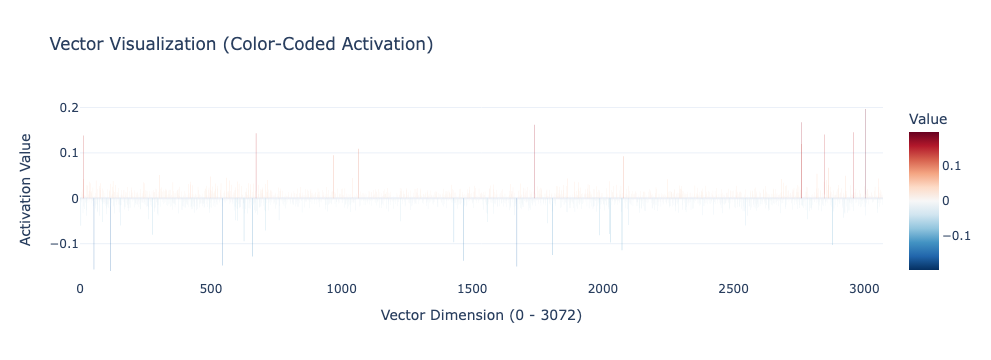

In [13]:
import plotly.express as px
import numpy as np

# Plot the vector as a sequence of bars
fig = px.bar(
    x=range(len(input_embd_vector)),
    y=input_embd_vector,
    # Crucial change: pass the values to 'color' to map them to a continuous scale
    color=input_embd_vector, 
    # Use a diverging color scale (Red for positive, Blue for negative)
    color_continuous_scale="RdBu_r", 
    labels={"x": f"Vector Dimension (0 - {len(input_embd_vector)})", "y": "Activation Value", "color": "Value"},
    title="Vector Visualization (Color-Coded Activation)",
    template="plotly_white"
)

# Style the bars to be sharp and distinct
fig.update_traces(marker_line_width=0)
fig.update_layout(
    bargap=0.1,
    coloraxis_cmid=0 
)

fig.show()

### Load first dataset with product descriptions

We use a [dataset of product information](https://dbs.uni-leipzig.de/file/Amazon-GoogleProducts.zip) scraped from Google and Amazon websites. The dataset is part of a [benchmark for semantic matching and entity resolution](https://dbs.uni-leipzig.de/research/projects/object_matching/benchmark_datasets_for_entity_resolution) from Leipzig University. It contains 3 tables which are included in this repo:

```python
../data/Amazon.csv.gz 
../data/GoogleProducts.csv.gz
../Amzon_GoogleProducts_perfectMapping.csv.gz

```

The first table contains product information listed on Amazon, including the product title, description, and manufacturer:

In [14]:
amazon = pd.read_csv("../data/Amazon.csv.gz")
amazon.columns = [
    "idAmazon",
    "amazon_title",
    "amazon_description",
    "amazon_manufacturer",
    "amazon_price",
]
amazon = amazon.dropna(subset=['amazon_description'])
amazon.head()

,idAmazon,amazon_title,amazon_description,amazon_manufacturer,amazon_price
1,b0006zf55o,ca international - arcserve lap/desktop oem 30pk,oem arcserve backup v11.1 win 30u for laptops and desktops,computer associates,0.00
3,b000g80lqo,peachtree by sage premium accounting for nonprofits 2007,peachtree premium accounting for nonprofits 2007 is the affordable easy to use accounting solution that provides you with donor/grantor management. if you're like most nonprofit organizations you're constantly striving to maximize each and every dollar of your annual operating budget. financial reporting by programs and funds advanced operational reporting and the rock-solid core accounting features that have made peachtree the choice of hundreds of thousands of small businesses. the result is an accounting solution tailor-made for the challenges of operating a nonprofit organization. keep an audit trail to record and report on any changes made to your transactions improve data integrity with prior period locking archive your organization's data for snap shots of your data before you closed your year set up individual user profiles with password protection peachtree restore wizard restores all backed-up data files plus web transactions and customized forms includes all standard acc...,sage software,599.99
4,b0006se5bq,singing coach unlimited,singing coach unlimited - electronic learning products (win me nt 2000 xp),carry-a-tune technologies,99.99
5,b000ehpzv8,emc retrospect 7.5 disk to disk windows,emc retrospect 7.5 disk to diskcromwindows,dantz,0.00
6,b00021xhzw,adobe after effects professional 6.5 upgrade from standard to professional,upgrade only; installation of after effects standard new disk caching tools speed up your interactive work save any combination of animation parameters as presets -- create transformations masks expressions effects and text tighter integration with other adobe tools - import photoshop cs and illustrator cs files with preserved layers and other attributes output to firewire for easier previewing on ntsc and pal video monitors,adobe,499.99


### Lets create embeddings for concatenated title and description with a space in between

In [15]:
import time
import logging
from tqdm.auto import tqdm # Great for showing a progress bar in Jupyter
import pandas as pd

# 1. Define your batch size
BATCH_SIZE = 20

# Concatenate Title and Description with a space in between
combined_text = amazon['amazon_title'].fillna('') + " " + amazon['amazon_description'].fillna('') #+ amazon['amazon_manufacturer'].fillna('')

# Convert to list and apply the truncation logic we used earlier
MAX_CHARS = 4000
descriptions = [str(text)[:MAX_CHARS] for text in combined_text.tolist()]

all_embeddings_768 = []

print(f"Starting to embed {len(descriptions)} documents in batches of {BATCH_SIZE}...")

# 3. Loop through the list in chunks
for i in tqdm(range(0, len(descriptions), BATCH_SIZE), desc="Embedding Batches"):
    # Slice the list to get the current batch
    batch_texts = descriptions[i : i + BATCH_SIZE]
    
    # Call embed_text function
    batch_embeddings_768 = embed_text(batch_texts)
    
    # Safety check: if the API call failed and returned an empty list, 
    # pad with None so our final list length matches the DataFrame length.
    if not batch_embeddings_768:
        print(f"Batch {i} to {i + BATCH_SIZE} failed. Padding with None.")
        batch_embeddings_768 = [None] * len(batch_texts)
        
    all_embeddings_768.extend(batch_embeddings_768)
    
    # Pause briefly to avoid hitting Requests-Per-Minute (RPM) limits.
    # Adjust this value based on your specific API quota.
    time.sleep(1.0) 

# 4. Assign the resulting embeddings back to the DataFrame
if len(all_embeddings_768) == len(amazon):
    amazon['amazon_embedding_768'] = all_embeddings_768
    print("Successfully added embeddings to the DataFrame!")
else:
    print(f"Length mismatch: {len(batch_embeddings_768)} embeddings for {len(amazon)} rows.")

# Temporarily restrict column width to 100 characters
with pd.option_context('display.max_colwidth', 100):
    display(amazon.head())

Starting to embed 1248 documents in batches of 20...


Embedding Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Successfully added embeddings to the DataFrame!


,idAmazon,amazon_title,amazon_description,amazon_manufacturer,amazon_price,amazon_embedding_768
1,b0006zf55o,ca international - arcserve lap/desktop oem 30pk,oem arcserve backup v11.1 win 30u for laptops and desktops,computer associates,0.00,"[0.0005078710964880884, -0.01966228149831295, 0.03119688667356968, -0.07006779313087463, -0.0166..."
3,b000g80lqo,peachtree by sage premium accounting for nonprofits 2007,peachtree premium accounting for nonprofits 2007 is the affordable easy to use accounting soluti...,sage software,599.99,"[0.0006390659837052226, -0.020075738430023193, 0.0045280177146196365, -0.04701819643378258, -0.0..."
4,b0006se5bq,singing coach unlimited,singing coach unlimited - electronic learning products (win me nt 2000 xp),carry-a-tune technologies,99.99,"[-0.008380795828998089, -0.0022354875691235065, 0.02206520549952984, -0.0727359727025032, -0.017..."
5,b000ehpzv8,emc retrospect 7.5 disk to disk windows,emc retrospect 7.5 disk to diskcromwindows,dantz,0.00,"[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0...."
6,b00021xhzw,adobe after effects professional 6.5 upgrade from standard to professional,upgrade only; installation of after effects standard new disk caching tools speed up your intera...,adobe,499.99,"[-0.0050449734553694725, 0.005919065326452255, 0.00457746023312211, -0.07457590848207474, -0.021..."


### Implement cosine similarity
Calculates cosine similarity between two embedding vectors.
Formula: (A · B) / (||A|| * ||B||)

In [16]:
import numpy as np
from numpy.linalg import norm

def calculate_cosine_similarity(embedding1, embedding2):
    """
    Calculates cosine similarity between two embedding vectors.
    Formula: (A · B) / (||A|| * ||B||)
    """ 
    # Calculate the dot product and the magnitudes
    dot_product = np.dot(embedding1, embedding2)
    magnitude = norm(embedding1) * norm(embedding2)
    
    # Avoid division by zero in case of an empty vector
    if magnitude == 0:
        return 0.0
        
    return dot_product / magnitude

### Example Usage
1. Generate an embedding for your search query (using our first function)
2. Apply the similarity function across the entire column
3. Sort the DataFrame to see the most relevant results at the top

In [17]:
amazon['cosine_similarity'] = amazon['amazon_embedding_768'].apply(
    lambda row_embedding: calculate_cosine_similarity(input_embd_vector, row_embedding)
)

amazon = amazon.sort_values(by='cosine_similarity', ascending=False)
# Temporarily restrict column width to 100 characters
with pd.option_context('display.max_colwidth', 100):
    display(amazon.head())

,idAmazon,amazon_title,amazon_description,amazon_manufacturer,amazon_price,amazon_embedding_768,cosine_similarity
5,b000ehpzv8,emc retrospect 7.5 disk to disk windows,emc retrospect 7.5 disk to diskcromwindows,dantz,0.00,"[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0....",0.990222
462,b000ehpzxq,emc retrospect 7.5 svr 1-client windows,emc retrospect 7.5 svr 1-client windows,dantz,249.00,"[-0.01095196045935154, 0.005057317204773426, -0.0073175448924303055, -0.0655815452337265, -0.015...",0.936391
90,b000ehq008,emc retrospect 7.5 professional for windows upgrade,upg emc retrospect 7.5 cromprofessional windows only,dantz,0.00,"[-0.0032504238188266754, 0.00707982899621129, -0.0008977520046755672, -0.0798879861831665, -0.02...",0.914782
132,b000ehpzyu,upgrade emc retrospect 7.5 multi server windows only,upg emc retrospect 7.5 multi cromserver windows only,dantz,0.00,"[-0.002048456110060215, -0.002951130038127303, -0.008127741515636444, -0.06753932684659958, -0.0...",0.904494
193,b000bw7kxw,backup exec 10d win adv disk v10.1 lic only (e180518),general information - manufacturer: symantec corporation. - manufacturer part number: e180518 - ...,symantec corporation.,983.34,"[-0.009442408569157124, -0.01336671132594347, 0.008926307782530785, -0.0557822547852993, -0.0038...",0.855740


### Visualize Similarity distribution
Plot the histogram of similarity distribution

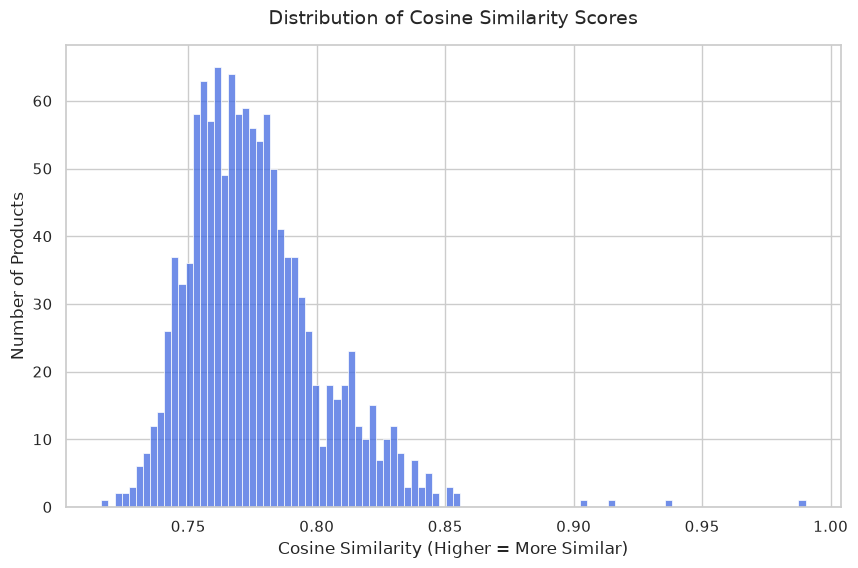

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Initialize the figure
plt.figure(figsize=(10, 6))

sns.histplot(
    amazon['cosine_similarity'],
    bins=100,
    kde=False,
    color='royalblue'
)

# Add titles and labels for readability
plt.title('Distribution of Cosine Similarity Scores', fontsize=14, pad=15)
plt.xlabel('Cosine Similarity (Higher = More Similar)', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Display the plot
plt.show()

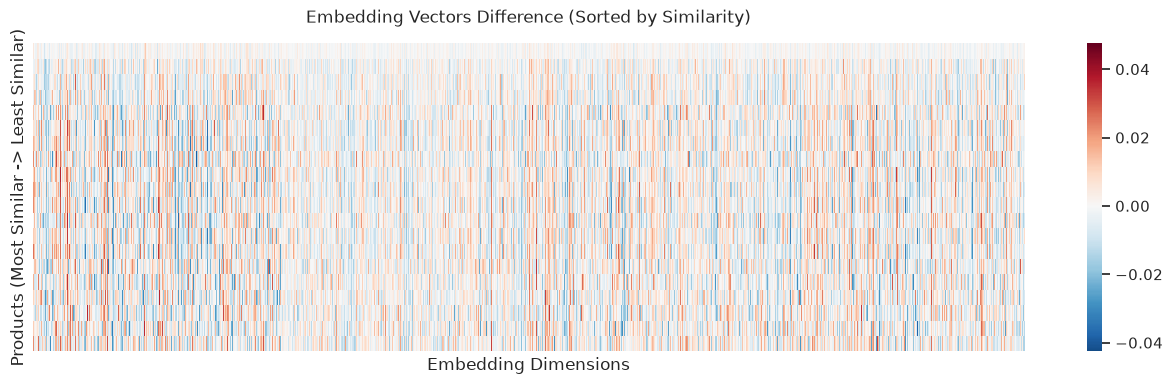

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a sample of a 10 top most similar records
sampled_df = amazon.iloc[:20]

# Stack the individual embedding arrays into a single 2D matrix and extract input vector
embedding_matrix = np.vstack(sampled_df['amazon_embedding_768'].values) - input_embd_vector

# 5. Plot the heatmap
plt.figure(figsize=(16, 4)) # Wide and short layout matching your image

# Create the heatmap
sns.heatmap(
    embedding_matrix,
    cmap='RdBu_r',     # Red-Blue diverging colormap
    center=0,          # Forces 0 to be pure white
    xticklabels=False, # Removes x-axis labels for a cleaner look
    yticklabels=False, # Removes y-axis labels
    cbar=True          # Shows the color scale on the right
)

plt.title("Embedding Vectors Difference (Sorted by Similarity)", pad=15)
plt.xlabel("Embedding Dimensions")
plt.ylabel("Products (Most Similar -> Least Similar)")

plt.show()

### Remove cosine_similarity column

In [20]:
amazon = amazon.drop(columns=["cosine_similarity"])

Calculate the L2 norm (Euclidean magnitude)
Lsts check is it L2 normalized

### 

In [21]:
import time
import logging
from tqdm.auto import tqdm # Great for showing a progress bar in Jupyter
import pandas as pd

amazon['amazon_embedding_128'] = [
    embed[:128] for embed in amazon['amazon_embedding_768'].tolist()
]

amazon['amazon_embedding_l2norm_128'] = [
    l2_normalize(embed[:128]) for embed in amazon['amazon_embedding_768'].tolist()
]

# Temporarily restrict column width to 100 characters
with pd.option_context('display.max_colwidth', 100):
    display(amazon.head())

,idAmazon,amazon_title,amazon_description,amazon_manufacturer,amazon_price,amazon_embedding_768,amazon_embedding_128,amazon_embedding_l2norm_128
5,b000ehpzv8,emc retrospect 7.5 disk to disk windows,emc retrospect 7.5 disk to diskcromwindows,dantz,0.00,"[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0....","[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0....","[-0.03742690216009426, 0.0013064197953568074, 0.001207181119891389, -0.18910873989723148, -0.039..."
462,b000ehpzxq,emc retrospect 7.5 svr 1-client windows,emc retrospect 7.5 svr 1-client windows,dantz,249.00,"[-0.01095196045935154, 0.005057317204773426, -0.0073175448924303055, -0.0655815452337265, -0.015...","[-0.01095196045935154, 0.005057317204773426, -0.0073175448924303055, -0.0655815452337265, -0.015...","[-0.033801158331824614, 0.015608454779148165, -0.022584220827612106, -0.20240505819194304, -0.04..."
90,b000ehq008,emc retrospect 7.5 professional for windows upgrade,upg emc retrospect 7.5 cromprofessional windows only,dantz,0.00,"[-0.0032504238188266754, 0.00707982899621129, -0.0008977520046755672, -0.0798879861831665, -0.02...","[-0.0032504238188266754, 0.00707982899621129, -0.0008977520046755672, -0.0798879861831665, -0.02...","[-0.00999420193831369, 0.021768619915665647, -0.0027603522879955833, -0.24563463439299715, -0.07..."
132,b000ehpzyu,upgrade emc retrospect 7.5 multi server windows only,upg emc retrospect 7.5 multi cromserver windows only,dantz,0.00,"[-0.002048456110060215, -0.002951130038127303, -0.008127741515636444, -0.06753932684659958, -0.0...","[-0.002048456110060215, -0.002951130038127303, -0.008127741515636444, -0.06753932684659958, -0.0...","[-0.006279055839130385, -0.009045988443165431, -0.02491366184125824, -0.20702577054219173, -0.06..."
193,b000bw7kxw,backup exec 10d win adv disk v10.1 lic only (e180518),general information - manufacturer: symantec corporation. - manufacturer part number: e180518 - ...,symantec corporation.,983.34,"[-0.009442408569157124, -0.01336671132594347, 0.008926307782530785, -0.0557822547852993, -0.0038...","[-0.009442408569157124, -0.01336671132594347, 0.008926307782530785, -0.0557822547852993, -0.0038...","[-0.029390882995729485, -0.04160585148811933, 0.027784443523994923, -0.17363045790964454, -0.011..."


### Load second dayaset
The second table contains the same information but for product information scrapped from Google website:

In [22]:
google = pd.read_csv("../data/GoogleProducts.csv.gz")
google.columns = [
    "idGoogleBase",
    "google_title",
    "google_description",
    "google_manufacturer",
    "google_price",
]
google = google.dropna(subset=['google_description'])
google.head()

,idGoogleBase,google_title,google_description,google_manufacturer,google_price
0,http://www.google.com/base/feeds/snippets/11125907881740407428,learning quickbooks 2007,learning quickbooks 2007,intuit,38.99
1,http://www.google.com/base/feeds/snippets/11538923464407758599,superstart! fun with reading & writing!,fun with reading & writing! is designed to help kids learn to read and write better through exercises puzzle-solving creative writing decoding and more!,NaN,8.49
2,http://www.google.com/base/feeds/snippets/11343515411965421256,qb pos 6.0 basic software,qb pos 6.0 basic retail mngmt software. for retailers who need basic inventory sales and customer tracking.,intuit,637.99
3,http://www.google.com/base/feeds/snippets/12049235575237146821,math missions: the amazing arcade adventure (grades 3-5),save spectacle city by disrupting randall underling's plan to drive all the stores out of business and take over the city. solve real-world math challenges in the uniquely entertaining stores and make theme successful again.,NaN,12.95
4,http://www.google.com/base/feeds/snippets/12244614697089679523,production prem cs3 mac upgrad,adobe cs3 production premium mac upgrade from production studio premium or standard,adobe software,805.99


In [23]:
import time
import logging
from tqdm.auto import tqdm # Great for showing a progress bar in Jupyter

# 1. Define your batch size
BATCH_SIZE = 20

# 2. Extract the descriptions as a standard Python list
#descriptions = google['google_description'].tolist()
combined_text = google['google_title'].fillna('') + " " + google['google_description'].fillna('')

# 2. Convert to list and apply the truncation logic we used earlier
MAX_CHARS = 4000
descriptions = [str(text)[:MAX_CHARS] for text in combined_text.tolist()]
all_embeddings = []

print(f"Starting to generate embeddings for {len(descriptions)} documents in batches of {BATCH_SIZE}...")

# 3. Loop through the list in chunks
for i in tqdm(range(0, len(descriptions), BATCH_SIZE), desc="Embedding Batches"):
    # Slice the list to get the current batch
    batch_texts = descriptions[i : i + BATCH_SIZE]
    
    # Call your optimized embed_text function
    batch_embeddings = embed_text(batch_texts)
    
    # Safety check: if the API call failed and returned an empty list, 
    # pad with None so our final list length matches the DataFrame length.
    if not batch_embeddings:
        logging.warning(f"Batch {i} to {i + BATCH_SIZE} failed. Padding with None.")
        batch_embeddings = [None] * len(batch_texts)
        
    all_embeddings.extend(batch_embeddings)
    
    # Pause briefly to avoid hitting Requests-Per-Minute (RPM) limits.
    # Adjust this value based on your specific API quota.
    time.sleep(1.0) 

# 4. Assign the resulting embeddings back to the DataFrame
if len(all_embeddings) == len(google):
    google['google_embedding_768'] = all_embeddings
    print("Successfully added embeddings to the DataFrame!")
else:
    print(f"Length mismatch: {len(all_embeddings)} embeddings for {len(google)} rows.")



import pandas as pd

# Temporarily restrict column width to 100 characters
with pd.option_context('display.max_colwidth', 100):
    display(google.head())

Starting to generate embeddings for 3035 documents in batches of 20...


Embedding Batches:   0%|          | 0/152 [00:00<?, ?it/s]

Successfully added embeddings to the DataFrame!


,idGoogleBase,google_title,google_description,google_manufacturer,google_price,google_embedding_768
0,http://www.google.com/base/feeds/snippets/11125907881740407428,learning quickbooks 2007,learning quickbooks 2007,intuit,38.99,"[-0.004453606903553009, -0.008442827500402927, 0.0004909372073598206, -0.050422992557287216, -0...."
1,http://www.google.com/base/feeds/snippets/11538923464407758599,superstart! fun with reading & writing!,fun with reading & writing! is designed to help kids learn to read and write better through exer...,NaN,8.49,"[0.0014326270902529359, 0.004960358142852783, 0.034295231103897095, -0.04564058035612106, -0.021..."
2,http://www.google.com/base/feeds/snippets/11343515411965421256,qb pos 6.0 basic software,qb pos 6.0 basic retail mngmt software. for retailers who need basic inventory sales and custome...,intuit,637.99,"[-0.008986841887235641, -0.015559038147330284, 0.011069566942751408, -0.06529340147972107, -0.02..."
3,http://www.google.com/base/feeds/snippets/12049235575237146821,math missions: the amazing arcade adventure (grades 3-5),save spectacle city by disrupting randall underling's plan to drive all the stores out of busine...,NaN,12.95,"[-0.03225180506706238, -0.009285811334848404, 0.023233361542224884, -0.0528782457113266, -0.0208..."
4,http://www.google.com/base/feeds/snippets/12244614697089679523,production prem cs3 mac upgrad,adobe cs3 production premium mac upgrade from production studio premium or standard,adobe software,805.99,"[0.0029036712367087603, -0.0015706813428550959, 0.008510810323059559, -0.0631871148943901, -0.02..."


In [24]:
import time
import logging
from tqdm.auto import tqdm # Great for showing a progress bar in Jupyter
import pandas as pd

google['google_embedding_128'] = [
    embed[:128] for embed in google['google_embedding_768'].tolist()
]

google['google_embedding_l2norm_128'] = [
    l2_normalize(embed[:128]) for embed in google['google_embedding_768'].tolist()
]

# Temporarily restrict column width to 100 characters
with pd.option_context('display.max_colwidth', 100):
    display(amazon.head())

,idAmazon,amazon_title,amazon_description,amazon_manufacturer,amazon_price,amazon_embedding_768,amazon_embedding_128,amazon_embedding_l2norm_128
5,b000ehpzv8,emc retrospect 7.5 disk to disk windows,emc retrospect 7.5 disk to diskcromwindows,dantz,0.00,"[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0....","[-0.012368638068437576, 0.00043173847370781004, 0.0003989426186308265, -0.06249562278389931, -0....","[-0.03742690216009426, 0.0013064197953568074, 0.001207181119891389, -0.18910873989723148, -0.039..."
462,b000ehpzxq,emc retrospect 7.5 svr 1-client windows,emc retrospect 7.5 svr 1-client windows,dantz,249.00,"[-0.01095196045935154, 0.005057317204773426, -0.0073175448924303055, -0.0655815452337265, -0.015...","[-0.01095196045935154, 0.005057317204773426, -0.0073175448924303055, -0.0655815452337265, -0.015...","[-0.033801158331824614, 0.015608454779148165, -0.022584220827612106, -0.20240505819194304, -0.04..."
90,b000ehq008,emc retrospect 7.5 professional for windows upgrade,upg emc retrospect 7.5 cromprofessional windows only,dantz,0.00,"[-0.0032504238188266754, 0.00707982899621129, -0.0008977520046755672, -0.0798879861831665, -0.02...","[-0.0032504238188266754, 0.00707982899621129, -0.0008977520046755672, -0.0798879861831665, -0.02...","[-0.00999420193831369, 0.021768619915665647, -0.0027603522879955833, -0.24563463439299715, -0.07..."
132,b000ehpzyu,upgrade emc retrospect 7.5 multi server windows only,upg emc retrospect 7.5 multi cromserver windows only,dantz,0.00,"[-0.002048456110060215, -0.002951130038127303, -0.008127741515636444, -0.06753932684659958, -0.0...","[-0.002048456110060215, -0.002951130038127303, -0.008127741515636444, -0.06753932684659958, -0.0...","[-0.006279055839130385, -0.009045988443165431, -0.02491366184125824, -0.20702577054219173, -0.06..."
193,b000bw7kxw,backup exec 10d win adv disk v10.1 lic only (e180518),general information - manufacturer: symantec corporation. - manufacturer part number: e180518 - ...,symantec corporation.,983.34,"[-0.009442408569157124, -0.01336671132594347, 0.008926307782530785, -0.0557822547852993, -0.0038...","[-0.009442408569157124, -0.01336671132594347, 0.008926307782530785, -0.0557822547852993, -0.0038...","[-0.029390882995729485, -0.04160585148811933, 0.027784443523994923, -0.17363045790964454, -0.011..."


The last table contains a matching of product information on both website corresponding to the same product, but possibly described differently on the two websites:

From this raw data, we have pre-generated for you an eval and test set:

```python
../data/product_matching_eval.csv
../data/product_matching_test.csv
```


We will use the eval set to design the prompt and use the test set to evaluate the Gemini API performance on this prompt. This way, the performance we report will be closer to the real performance on never-seen-pairs of product descriptions.  


To genrate the eval and test split, we used the function in the cell below. It takes a sample (whose size is controlled by `SAMPLE_SIZE`) of matching product ID's in the `matching` dataframe, and it joins the information of the Google and Amazon product information contained in the `google` and `amazon` dataframes. Then it extracts pairs of matching Google and Amazon descriptions and creates a table of matching descriptions with columns `description_1` (Google), `description_2` (Amazon), and a target column named `match` whose value is set to `yes` since we have only matching pairs so far.
To create description pairs of not matching product, we permutate the second description columns while keeping the first description fixed, and concatenate this new dataframe of not matching descriptions to the one of matching description. We shuffle and then split the resulting table into two equal sized dataframes, which we save on disk as our eval and test splits. 

Observe that we only use the `title` column as product description. So there is much more info in the raw data. Nevertheless, we will see that Gemini will achieve a performance close to 100% on the test set. Remarkable!

**Note:** Uncomment the last line if you want to re-generate the eval and test set on a different sample of the data.

In [54]:
matching = pd.read_csv("../data/Amzon_GoogleProducts_perfectMapping.csv.gz")

matching = matching.merge(right=google, how="left", on="idGoogleBase")
matched_products = matching.merge(right=amazon, how="left", on="idAmazon")
matched_products = matched_products.dropna(subset=['amazon_description'])
matched_products = matched_products.dropna(subset=['google_description'])
matched_products = matched_products[:1000] # Using just first 1000 matched products pairs
with pd.option_context('display.max_colwidth', 100):
    display(matched_products.head())

,idAmazon,idGoogleBase,google_title,google_description,google_manufacturer,google_price,google_embedding_768,google_embedding_128,google_embedding_l2norm_128,amazon_title,amazon_description,amazon_manufacturer,amazon_price,amazon_embedding_768,amazon_embedding_128,amazon_embedding_l2norm_128
2,b000g80lqo,http://www.google.com/base/feeds/snippets/18441188461196475272,sage (ptree) - vernfp2007rt - premium accounting for nonprofits 2007,if you're like most nonprofit organizations you're constantly striving to maximize each and ever...,NaN,590.35,"[-0.0040772235952317715, -0.011743518523871899, -0.009351457469165325, -0.06103060394525528, -0....","[-0.0040772235952317715, -0.011743518523871899, -0.009351457469165325, -0.06103060394525528, -0....","[-0.012773434890233104, -0.03679098429194609, -0.02929695424378047, -0.19120129853020898, -0.092...",peachtree by sage premium accounting for nonprofits 2007,peachtree premium accounting for nonprofits 2007 is the affordable easy to use accounting soluti...,sage software,599.99,"[0.0006390659837052226, -0.020075738430023193, 0.0045280177146196365, -0.04701819643378258, -0.0...","[0.0006390659837052226, -0.020075738430023193, 0.0045280177146196365, -0.04701819643378258, -0.0...","[0.00197671463132215, -0.06209688342217879, 0.014005750729337987, -0.1454334281574083, -0.066221..."
3,b0006se5bq,http://www.google.com/base/feeds/snippets/18428750969726461849,singing coach unlimited - electronic learning products,learn to sing with the help of a patented real-time pitch recognition technology. twenty lesson ...,NaN,82.5,"[-0.008357265032827854, 0.00023449207947123796, 0.010558854788541794, -0.07123427093029022, 0.00...","[-0.008357265032827854, 0.00023449207947123796, 0.010558854788541794, -0.07123427093029022, 0.00...","[-0.024678232720133232, 0.0006924334797913051, 0.031179324181556674, -0.21034823100158276, 0.009...",singing coach unlimited,singing coach unlimited - electronic learning products (win me nt 2000 xp),carry-a-tune technologies,99.99,"[-0.008380795828998089, -0.0022354875691235065, 0.02206520549952984, -0.0727359727025032, -0.017...","[-0.008380795828998089, -0.0022354875691235065, 0.02206520549952984, -0.0727359727025032, -0.017...","[-0.025804143736711086, -0.0068829791027363516, 0.06793790779628188, -0.22395122524650096, -0.05..."
4,b00021xhzw,http://www.google.com/base/feeds/snippets/18430621475529168165,adobe software 22070152 after effects 6.5 pbupgrd,adobe after effects pb 6.5 win upgrade.standard to pro v6.5 upgrademodel- adbcd36149wi vendor- a...,NaN,507,"[-0.012792975641787052, 0.01101494487375021, -0.0002863193803932518, -0.07754793018102646, -0.02...","[-0.012792975641787052, 0.01101494487375021, -0.0002863193803932518, -0.07754793018102646, -0.02...","[-0.03980441597050954, 0.03427220217748642, -0.0008908619883840824, -0.2412847610289376, -0.0646...",adobe after effects professional 6.5 upgrade from standard to professional,upgrade only; installation of after effects standard new disk caching tools speed up your intera...,adobe,499.99,"[-0.0050449734553694725, 0.005919065326452255, 0.00457746023312211, -0.07457590848207474, -0.021...","[-0.0050449734553694725, 0.005919065326452255, 0.00457746023312211, -0.07457590848207474, -0.021...","[-0.015431706016810634, 0.018105402698381297, 0.0140016634866533, -0.2281148762848485, -0.065965..."
5,b0000dbykm,http://www.google.com/base/feeds/snippets/18434163358494173665,kutoka interactive 61208 mia's math adventure: just in time!,mia's math adventure tells a captivating story with educational activities. games focus on devel...,kutoka interactive,24.99,"[-0.014567784033715725, -0.006878652609884739, 0.020511170849204063, -0.06112249195575714, -0.00...","[-0.014567784033715725, -0.006878652609884739, 0.020511170849204063, -0.06112249195575714, -0.00...","[-0.04379353286652478, -0.020678539608440228, 0.06166048539960471, -0.18374585003135838, -0.0124...",mia's math adventure: just in time,in mia's math adventure: just in time chi

### Lets use semantic search

The similarity_func now expects exactly two single values (e.g., two strings or two 1D arrays) to evaluate at a time. This is indeed much slower, but it is the perfect setup for micro-benchmarking or profiling how efficiently a specific distance or similarity algorithm performs per call.

In [55]:
import time
import numpy as np
import pandas as pd

def evaluate_matching_ranked(df, col_amazon, col_google, similarity_func, is_distance=False):
    """
    Evaluates matches between Amazon and Google columns and ranks all combinations.
    
    Returns:
    - result_df: DataFrame with appended ranking lists (1 to N) and Top-K metrics.
    """
    result_df = df.copy()
    
    amazon_data = result_df[col_amazon].tolist()
    google_data = result_df[col_google].tolist()
    
    # Extract the ground truth IDs to map back to our predictions
    google_ids = result_df['idGoogleBase'].values 
    
    N = len(amazon_data)
    M = len(google_data)
    
    metric_type = "distance" if is_distance else "similarity"
    print(f"Calculating {metric_type} iteratively for {N} x {M} ({N * M:,}) combinations...")
    
    similarity_matrix = np.zeros((N, M))
    start_time = time.perf_counter()

    # --- Full Iteration Logic ---
    # We compare every Amazon item to every Google item.
    for i in range(N):
        for j in range(M): 
            similarity_matrix[i, j] = similarity_func(amazon_data[i], google_data[j])
            
    end_time = time.perf_counter()

    # --- Calculate Performance Metrics ---
    execution_time = end_time - start_time
    
    # --- Ranking Logic ---
    # np.argsort returns the indices that would sort the array. 
    if is_distance:
        # For distances, lower is better (ascending sort)
        ranked_indices = np.argsort(similarity_matrix, axis=1)
    else:
        # For similarities, higher is better (descending sort)
        # We use negative similarity_matrix to sort highest-to-lowest
        ranked_indices = np.argsort(-similarity_matrix, axis=1)

    # Pre-allocate lists for our new DataFrame columns
    all_ranked_ids = []
    all_ranked_scores = []
    correct_match_ranks = []

    for i in range(N):
        # Extract the sorted indices for this specific Amazon row
        row_sorted_indices = ranked_indices[i]
        
        # Reorder the IDs and Scores based on the sorted indices
        sorted_scores = similarity_matrix[i, row_sorted_indices]
        sorted_ids = google_ids[row_sorted_indices]
        
        all_ranked_ids.append(sorted_ids.tolist())
        all_ranked_scores.append(sorted_scores.tolist())
        
        # Calculate what rank the actual correct ID achieved (1-based indexing)
        true_id = result_df['idGoogleBase'].iloc[i]
        rank_pos = np.where(sorted_ids == true_id)[0]
        
        if len(rank_pos) > 0:
            correct_match_ranks.append(rank_pos[0] + 1) # +1 so rank starts at 1, not 0
        else:
            correct_match_ranks.append(None)
            
    # --- Assigning to DataFrame ---
    result_df['ranked_predicted_idGoogleBase'] = all_ranked_ids
    result_df['ranked_scores'] = all_ranked_scores
    result_df['correct_match_rank'] = correct_match_ranks
    
    # Preserve original logic: isolate the #1 best match
    result_df['predicted_idGoogleBase'] = [ids[0] for ids in all_ranked_ids]
    result_df['best_match_score'] = [scores[0] for scores in all_ranked_scores]
    result_df['is_correct_match'] = result_df['idGoogleBase'] == result_df['predicted_idGoogleBase']
    
    # Only calculate the diagonal pair score if the matrix is perfectly square
    if N == M:
        result_df['pair_score'] = similarity_matrix.diagonal()
    else:
        result_df['pair_score'] = None
    
    total_comparisons = N * M
    
    # Calculate Top-K Accuracies
    top_1_acc = (result_df['correct_match_rank'] == 1).mean() * 100
    top_3_acc = (result_df['correct_match_rank'] <= 3).mean() * 100
    top_5_acc = (result_df['correct_match_rank'] <= 5).mean() * 100
    top_10_acc = (result_df['correct_match_rank'] <= 10).mean() * 100
    top_20_acc = (result_df['correct_match_rank'] <= 20).mean() * 100
    
    print("-" * 40)
    print(f"Execution time: {execution_time:.4f} seconds")
    print(f"Total pairwise comparisons calculated: {total_comparisons:,}")
    print(f"Average time per comparison: {(execution_time / total_comparisons) * 1e6:.2f} microseconds")
    print("-" * 40)
    print("Model Accuracy (Where did the correct match rank?):")
    print(f"Best Match Accuracy: {top_1_acc:.2f}%")
    print(f"Top-3 Accuracy: {top_3_acc:.2f}%")
    print(f"Top-5 Accuracy: {top_5_acc:.2f}%")
    print(f"Top-10 Accuracy: {top_10_acc:.2f}%")
    print(f"Top-20 Accuracy: {top_20_acc:.2f}%")
    print("-" * 40)
    
    return result_df

In [56]:
# Function takes two individual 1D arrays
def cosine_sim_item(vec1, vec2):
    norm_product = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if norm_product == 0:
        return 0.0
    return np.dot(vec1, vec2) / norm_product

def dot_product(vec1, vec2):
    return np.dot(vec1, vec2)

import numpy as np

def euclidean_dist(vector1, vector2):
    # 1. Calculate the Euclidean distance
    # np.linalg.norm calculates the square root of the sum of squared differences
    distance = np.sqrt(np.sum((vector1 - vector2) ** 2))
    return distance

# vector_results1 = evaluate_matching_ranked(
#     df=matched_products, 
#     col_amazon='amazon_embedding_768', 
#     col_google='google_embedding_768', 
#     similarity_func=cosine_sim_item
# )

# vector_results1 = evaluate_matching_ranked(
#     df=matched_products, 
#     col_amazon='amazon_embedding_128', 
#     col_google='google_embedding_128', 
#     similarity_func=cosine_sim_item
# )
    
# vector_results2 = evaluate_matching_ranked(
#     df=matched_products, 
#     col_amazon='amazon_embedding_768', 
#     col_google='google_embedding_768', 
#     similarity_func=dot_product
# )

vector_results2 = evaluate_matching_ranked(
    df=matched_products, 
    col_amazon='amazon_embedding_128', 
    col_google='google_embedding_128', 
    similarity_func=dot_product
)

vector_results2 = evaluate_matching_ranked(
    df=matched_products, 
    col_amazon='amazon_embedding_l2norm_128', 
    col_google='google_embedding_l2norm_128',  
    similarity_func=dot_product
)

vector_results2 = evaluate_matching_ranked(
    df=matched_products, 
    col_amazon='amazon_embedding_768', 
    col_google='google_embedding_768',
    similarity_func=euclidean_dist,
    is_distance=True
)

vector_results2 =  evaluate_matching_ranked(
    df=matched_products, 
    col_amazon='amazon_embedding_128', 
    col_google='google_embedding_128', 
    similarity_func=euclidean_dist,
    is_distance=True
)

# # Test your function manually
# vec1 = matched_products['amazon_embedding_l2norm_128'].iloc[0]
# vec2 = matched_products['google_embedding_l2norm_128'].iloc[0]

# # Convert to numpy arrays just in case your function expects them
# # import numpy as np
# # vec1 = np.array(vec1)
# # vec2 = np.array(vec2)

# dist = euclidean_dist(vec1, vec2)
# print(f"Data type of vec1: {type(vec1)}")
# print(f"Calculated distance: {dist}")

vector_results2 =  evaluate_matching_ranked(
    df=matched_products, 
    col_amazon='amazon_embedding_l2norm_128', 
    col_google='google_embedding_l2norm_128', 
    similarity_func=euclidean_dist,
    is_distance=True
)

Calculating similarity iteratively for 1000 x 1000 (1,000,000) combinations...
----------------------------------------
Execution time: 1.4137 seconds
Total pairwise comparisons calculated: 1,000,000
Average time per comparison: 1.41 microseconds
----------------------------------------
Model Accuracy (Where did the correct match rank?):
Best Match Accuracy: 26.20%
Top-3 Accuracy: 42.30%
Top-5 Accuracy: 50.70%
Top-10 Accuracy: 59.70%
Top-20 Accuracy: 67.70%
----------------------------------------
Calculating similarity iteratively for 1000 x 1000 (1,000,000) combinations...
----------------------------------------
Execution time: 1.3036 seconds
Total pairwise comparisons calculated: 1,000,000
Average time per comparison: 1.30 microseconds
----------------------------------------
Model Accuracy (Where did the correct match rank?):
Best Match Accuracy: 46.90%
Top-3 Accuracy: 64.40%
Top-5 Accuracy: 72.00%
Top-10 Accuracy: 78.60%
Top-20 Accuracy: 83.60%
-----------------------------------

In [67]:
import numpy as np
import pandas as pd

def get_top_matches_for_amazon_product(amazon_idx, df, top_k=5):
    """
    Finds the top K closest Google products for a single Amazon product.
    Returns a DataFrame containing the Amazon product info, the ranked Google matches,
    and a boolean column indicating if it's the correct ground-truth match.
    """
    # 1. Get target Amazon vector for distance calculation
    amazon_vector = np.array(df['amazon_embedding_l2norm_128'].iloc[amazon_idx])
    
    # Extract the true Google ID for this specific Amazon product (Ground Truth)
    true_google_id = df['idGoogleBase'].iloc[amazon_idx]
    
    # 2. Extract Amazon-specific columns, EXCLUDING the heavy embedding vectors
    columns_to_exclude = {
        'amazon_embedding_768', 
        'amazon_embedding_128', 
        'amazon_embedding_l2norm_128'
    }
    
    amazon_cols = [
        col for col in df.columns 
        if ('amazon' in col.lower() or col == 'idAmazonBase') 
        and col not in columns_to_exclude
    ]
    amazon_data = df.iloc[amazon_idx][amazon_cols].to_dict()
    
    # 3. Extract Google matrix and calculate distances
    google_matrix = np.stack(df['google_embedding_l2norm_128'].values)
    distances = np.linalg.norm(google_matrix - amazon_vector, axis=1)
    
    # 4. Sort distances ascending to get Top-K indices
    best_match_indices = np.argsort(distances)[:top_k]
    
    # 5. Build the resulting rows
    results = []
    google_cols = ['idGoogleBase', 'google_title', 'google_description', 'google_manufacturer', 'google_price']
    
    for rank_zero_indexed, google_idx in enumerate(best_match_indices):
        # Start with the filtered Amazon data
        row_dict = amazon_data.copy()
        
        # Add the ranking metrics
        row_dict['match_rank'] = rank_zero_indexed + 1
        row_dict['distance_score'] = distances[google_idx]
        
        # Add the corresponding Google data safely
        for g_col in google_cols:
            if g_col in df.columns:
                row_dict[g_col] = df[g_col].iloc[google_idx]
            else:
                row_dict[g_col] = None 
                
        # --- NEW: Check if this predicted Google ID matches the true Google ID ---
        row_dict['is_correct_match'] = (row_dict.get('idGoogleBase') == true_google_id)
                
        results.append(row_dict)
        
    # 6. Return as a clean DataFrame
    return pd.DataFrame(results)

# Example usage: Get top 5 matches for the very first Amazon product (Row 0)
rearch_results = get_top_matches_for_amazon_product(amazon_idx=0, df=matched_products, top_k=5)

In [61]:
# Filter the DataFrame
related_records = vector_results2[vector_results2['idAmazon'] == 'b000f613x2']

print(f"Found {len(related_records)} records where actual match ranked 5: {target_amazon_id}")
display(related_records) # Use print(related_records) if not in a Jupyter Notebook

Found 1 records where actual match ranked 5: b000g80lqo


,idAmazon,idGoogleBase,google_title,google_description,google_manufacturer,google_price,google_embedding_768,google_embedding_128,google_embedding_l2norm_128,amazon_title,...,amazon_embedding_768,amazon_embedding_128,amazon_embedding_l2norm_128,ranked_predicted_idGoogleBase,ranked_scores,correct_match_rank,predicted_idGoogleBase,best_match_score,is_correct_match,pair_score
95,b000f613x2,http://www.google.com/base/feeds/snippets/18428018889032699615,viva media llc 00257 - my sim aquarium - win 2000 xp vista,viva media llc 00257 : my sim aquarium is a virtual pet game designed for players who love fish and aquatic creatures. this simulation game turns your computer into a virtual environment for your pet fish to live in with you as their keeper. as with ...,NaN,19.97,"[-0.019229717552661896, -0.019649429246783257, 0.010812310501933098, -0.07290422916412354, -0.016969583928585052, 0.008721780963242054, -0.007586007937788963, -0.004753544926643372, 0.029717575758695602, -0.004581833258271217, -0.007180333137512207, -0.00819169171154499, -0.020554091781377792, 0.038381177932024, 0.13307501375675201, -0.015382411889731884, -0.008913678117096424, -0.004054595250636339, 0.024226710200309753, -0.0032993771601468325, -0.012050890363752842, -0.007415151689201593, 0.02389718033373356, -0.048964060842990875, 0.012462650425732136, -0.026123451068997383, 0.04851888492703438, -0.006326459348201752, 0.021996106952428818, -0.021803950890898705, -0.01419291365891695, 0.015480143018066883, 0.0018278968054801226, 0.0031003097537904978, 0.010677449405193329, -0.006426217034459114, 0.011946382001042366, 0.0035783802159130573, 0.021032065153121948, 0.03277774900197983, -0.017028773203492165, 0.000707806262653321, -0.017180439084768295, 0.004633318167179823, 0.0165634...","[-0.019229717552661896, -0.019649429246783257, 0.010812310501933098, -0.07290422916412354, -0.016969583928585052, 0.008721780963242054, -0.007586007937788963, -0.004753544926643372, 0.029717575758695602, -0.004581833258271217, -0.007180333137512207, -0.00819169171154499, -0.020554091781377792, 0.038381177932024, 0.13307501375675201, -0.015382411889731884, -0.008913678117096424, -0.004054595250636339, 0.024226710200309753, -0.0032993771601468325, -0.012050890363752842, -0.007415151689201593, 0.02389718033373356, -0.048964060842990875, 0.012462650425732136, -0.026123451068997383, 0.04851888492703438, -0.006326459348201752, 0.021996106952428818, -0.021803950890898705, -0.01419291365891695, 0.015480143018066883, 0.0018278968054801226, 0.0031003097537904978, 0.010677449405193329, -0.006426217034459114, 0.011946382001042366, 0.0035783802159130573, 0.021032065153121948, 0.03277774900197983, -0.017028773203492165, 0.000707806262653321, -0.017180439084768295, 0.004633318167179823, 0.0165634...","[-0.05719033794527367, -0.058438585797102434, 0.032156462510765704, -0.21682156756164864, -0.05046856445024186, 0.02593910177861247, -0.022561244408793917, -0.014137328853025379, 0.08838185979069728, -0.013626648011434395, -0.021354743124509714, -0.024362584424018473, -0.06112910665047438, 0.1141479343447914, 0.39577310420594736, -0.045748219232964515, -0.02650981546952409, -0.012058610428372885, 0.07205169498010279, -0.009812546350770229, -0.03584007360259249, -0.022053107637153152, 0.07107165331381504, -0.1456220653847284, 0.03706467282161237, -0.07769271653841693, 0.14429808540379913, -0.01881527105792616, 0.06541774660208946, -0.06484626290415971, -0.04221057986726336, 0.04603887749364593, 0.005436275168795893, 0.009220507897151238, 0.03175537748821684, -0.019111956423900626, 0.035529259438778, 0.010642318239168332, 0.06255062823985967, 0.09748299928872817, -0.050644596917978485, 0.002105058446649994, -0.0510956603816615, 0.013779767230762565, 0.04926065610277343, 0.01664093327...",my sim aquarium,...,"[-0.007088016718626022, -0.02190050296485424, 0.02395172044634819, -0.09150206297636032, -0.007630921900272369, 0.0031032704282552004, 0.005887582898139954, -0.0017942854901775718, 0.01887017488479

The next cell loads the eval and test datasets that we pre-generated. The two CSV files contain 60 examples of product description pairs. Each pair is labeled with a `match` value of `yes` if the descriptions describe the same product and `no` otherwise. `description_1` comes from product title on Google while `description_2` comes from Amazon products.

In [ ]:
full_dataset = pd.read_csv("../data/full_dataset.csv")

Let's have a quick look at a few entries in this dataset:

In [ ]:
full_dataset.head()

Both splits are roughly balanced. To make sure that both splits are roughly balanced, we count the number of class instances for each split.

In [ ]:
full_dataset.match.value_counts()

# WIP

Finding Mismatches Error Analysis

# Rerank Model implementation

We start by instanciating our client using the Gen AI SDK. We'll use the `gemini-2.5-flash` version of Gemini which is a large language model (LLM) developed by Google.

In [68]:
MODEL = "gemini-2.5-flash"

client = genai.Client(vertexai=True, location="us-central1")

Using this client, we implement in the next cell a simple function that takes two product descriptions and a parameterized prompt as input, and outputs `yes` or `no` depending on whether the Gemini model thinks the product descriptions are matching.

In [69]:
def are_products_matching(d1, d2, prompt):
    prompt = prompt.format(desc1=d1, desc2=d2)
    generation_config = GenerateContentConfig(
        temperature=0.1,
        top_p=0.8,
        top_k=40,
    )
    answer = client.models.generate_content(
        model=MODEL, contents=prompt, config=generation_config
    )
    return answer.text.strip()

The next cell allows us to rapidly test on the evaluation set whether a given prompt seems to be working for this use case.

In [73]:
PROMPT = """
Are the following two descriptions describing the same product?

EXAMPLE:

Description 1: {desc1}
Description 2: {desc2}

If they are similar, reply with "yes" and if they are not similar, reply with "no".
Answer only with "yes" or "no"
"""

index=0 #= random.randint(0, len(false_negatives) - 1)

d1 = rearch_results.iloc[index]["amazon_description"]
d2 = rearch_results.iloc[index]["google_description"]
#ground_truth = rearch_results.iloc[index]["match"]
prediction = are_products_matching(d1, d2, prompt=PROMPT)


print(
    f"""
Are the following two descriptions describing the same product?

Description 1: {d1}

Descriptions 2: {d2}

MODEL ANSWER: {prediction}
"""
#GROUND TRUTH: {ground_truth}
)


Are the following two descriptions describing the same product?

Description 1: peachtree premium accounting for nonprofits 2007 is the affordable easy to use accounting solution that provides you with donor/grantor management. if you're like most nonprofit organizations you're constantly striving to maximize each and every dollar of your annual operating budget. financial reporting by programs and funds advanced operational reporting and the rock-solid core accounting features that have made peachtree the choice of hundreds of thousands of small businesses. the result is an accounting solution tailor-made for the challenges of operating a nonprofit organization. keep an audit trail to record and report on any changes made to your transactions improve data integrity with prior period locking archive your organization's data for snap shots of your data before you closed your year set up individual user profiles with password protection peachtree restore wizard restores all backed-up da

# Model Analysis

We now analyze the performance of our model on the test set.

Large language models may sometimes output something other than "yes" or "no," even if we ask them politely to do so. This could be due to safety filters being triggered or the model simply not understanding the question. Therefore, we first need to determine the proportion of requests that our model fails to answer. In this case, it is around 6%, which may be acceptable. Further prompt engineering or model tuning could help to reduce this number.

The second aspect to consider is the performance of the model on the requests
that succeded (i.e. for whose the output was actually `yes` or `no`).
Since the test set is balanced, we can compute the model accuracy, which is 98%. This means that only a single example in the test set received a prediction that was different from the ground truth.

## Scoring the test set

To simplify evaluation, we implement a function in the next cell that will add a `prediction` column to our `testset`. This column will contain the predictions received from the Gemini API:

In [ ]:
def apply_prompt(prompt, dataset):
    scored_dataset = dataset.copy()
    scored_dataset["predictions"] = scored_dataset.apply(
        lambda row: are_products_matching(
            row.description_1, row.description_2, prompt=PROMPT
        ),
        axis=1,
    )
    return scored_dataset

Let's apply this function to our `testset` using our simple prompt that we designed on the `evalset`:

In [ ]:
scored_testset = apply_prompt(prompt=PROMPT, dataset=false_negatives)

Since requests to the Gemini API are limited and capped to 60 requests per minute, we save our scoring to disk so that we can analyze it offline if needed.

In [ ]:
scored_testset.to_csv("scored_evalset.csv", index=False)

Here are the predictions of our model. We can see that most examples are classified correctly, although some requests failed, resulting in empty predictions. We will need to analyze these cases separately and compute the accuracy only for the requests that succeeded:

In [ ]:
scored_testset.head(10)

### Failed predictions

The cell below list the number of failed predictions, that is, predictions which are anything other that `yes` or `no`. There are several possible causes to such a behavior. Gemini, as all LLM's, has been trained to predict the next most likely word from a sequence of words. Therefore, although we instruct Gemini explicitely in our prompt to answer by `yes` or `no`, it may happen that certain product descriptions confuse Gemini, resulting in something different from `yes` or `no`. Another issue is that the language in the product descriptions may trigger a safety filter, which then will replace Gemini raw answer by some standard warning text. These safety filters can be triggered by words in the product descriptions that are too evocating of health or medical issues for instance, or violence, among many [other safety settings](https://developers.generativeai.google/guide/safety_setting). 

In [ ]:
failed_predictions_mask = ~(
    scored_testset.predictions.str.match("yes")
    | scored_testset.predictions.str.match("no")
)

failed_predictions_mask.value_counts()

In [ ]:
proportion_of_failed_predictions = failed_predictions_mask.sum() / len(
    failed_predictions_mask
)
print(
    "Proportion of failed requests:",
    round(proportion_of_failed_predictions, 3) * 100,
    "%",
)

The next cell examines the failed requests. Some of the terms may have triggered safety filters, but this would require further investigation:

In [ ]:
scored_testset[failed_predictions_mask]

## Accuracy on succeeded predictions

Let us now compute the model accuracy on the requests that succeeded. First, we remove all the failed requests from the test set:

In [ ]:
scored_testset_with_predictions = scored_testset[~failed_predictions_mask]

Then, we compute the number of correct answers:

In [ ]:
is_prediction_correct = (
    scored_testset_with_predictions.match
    == scored_testset_with_predictions.predictions
)
is_prediction_correct.value_counts()

The accuracy of our model is the number of correct answers divided by the number of predictions that succeeded, which we compute below:


In [ ]:
model_accuracy = is_prediction_correct.sum() / len(is_prediction_correct)
print("Model accuracy:", round(model_accuracy, 3))

Actually, for our small test set, this corresponds to our model having made the following number of errors:

In [ ]:
uncorrect_predictions_mask = (
    scored_testset_with_predictions.match
    != scored_testset_with_predictions.predictions
)
sum(uncorrect_predictions_mask)

We can now inspect the errors:

In [ ]:
scored_testset_with_predictions[uncorrect_predictions_mask]

Copyright 2025 Google LLC

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0
Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.